C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:68: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray.ravel(), 256, [0, 256], color='gray', alpha=0.7, label='Original')
C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:73: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray_eq.ravel(), 256, [0, 256], color='black', alpha=0.7, label='Equalized')
C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:79: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(y_original.ravel(), 256, [0, 256], color='orange', alpha=0.7, label='Original Y')
C:\Users\MSI\AppData\Local\Temp\ipy

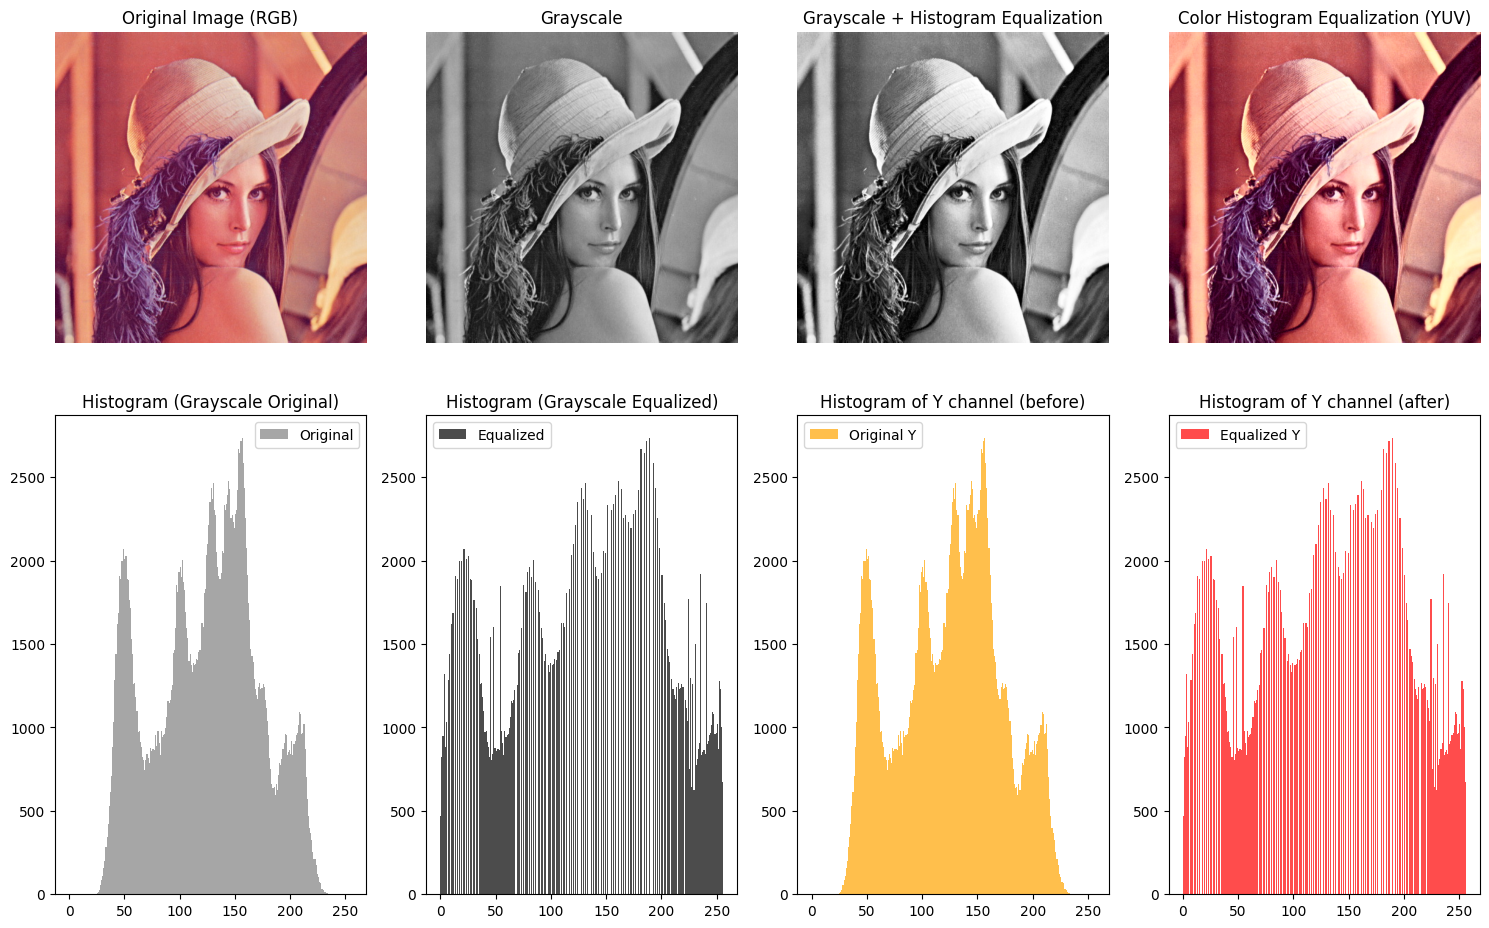

In [2]:
# Histogram Equalisation
import cv2
import numpy as np
import matplotlib.pyplot as plt


# =============================================
# Read the image
# =============================================
img = cv2.imread('lena.jpg')

# Convert from BGR (OpenCV default) to RGB for proper display with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =============================================
# 1. Grayscale Histogram Equalization
# =============================================
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization
img_gray_eq = cv2.equalizeHist(img_gray)

# =============================================
# 2. Color Histogram Equalization (using YUV color space)
# =============================================
# Convert to YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Equalize only the Y (luminance) channel
y_original = img_yuv[:,:,0].copy()

img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])

# Convert back to BGR and then to RGB for display
img_color_eq = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

# =============================================
# Plotting results
# =============================================
plt.figure(figsize=(15, 10))

# Original RGB image
plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Original Image (RGB)')
plt.axis('off')

# Grayscale original
plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

# Grayscale equalized
plt.subplot(2, 4, 3)
plt.imshow(img_gray_eq, cmap='gray')
plt.title('Grayscale + Histogram Equalization')
plt.axis('off')

# Color equalized
plt.subplot(2, 4, 4)
plt.imshow(img_color_eq)
plt.title('Color Histogram Equalization (YUV)')
plt.axis('off')

# Histograms for grayscale
plt.subplot(2, 4, 5)
plt.hist(img_gray.ravel(), 256, [0, 256], color='gray', alpha=0.7, label='Original')
plt.title('Histogram (Grayscale Original)')
plt.legend()

plt.subplot(2, 4, 6)
plt.hist(img_gray_eq.ravel(), 256, [0, 256], color='black', alpha=0.7, label='Equalized')
plt.title('Histogram (Grayscale Equalized)')
plt.legend()

# Histograms for luminance channel (Y) in color image
plt.subplot(2, 4, 7)
plt.hist(y_original.ravel(), 256, [0, 256], color='orange', alpha=0.7, label='Original Y')
plt.title('Histogram of Y channel (before)')
plt.legend()

plt.subplot(2, 4, 8)
plt.hist(img_yuv[:,:,0].ravel(), 256, [0, 256], color='red', alpha=0.7, label='Equalized Y')
plt.title('Histogram of Y channel (after)')
plt.legend()

plt.tight_layout()
plt.show()


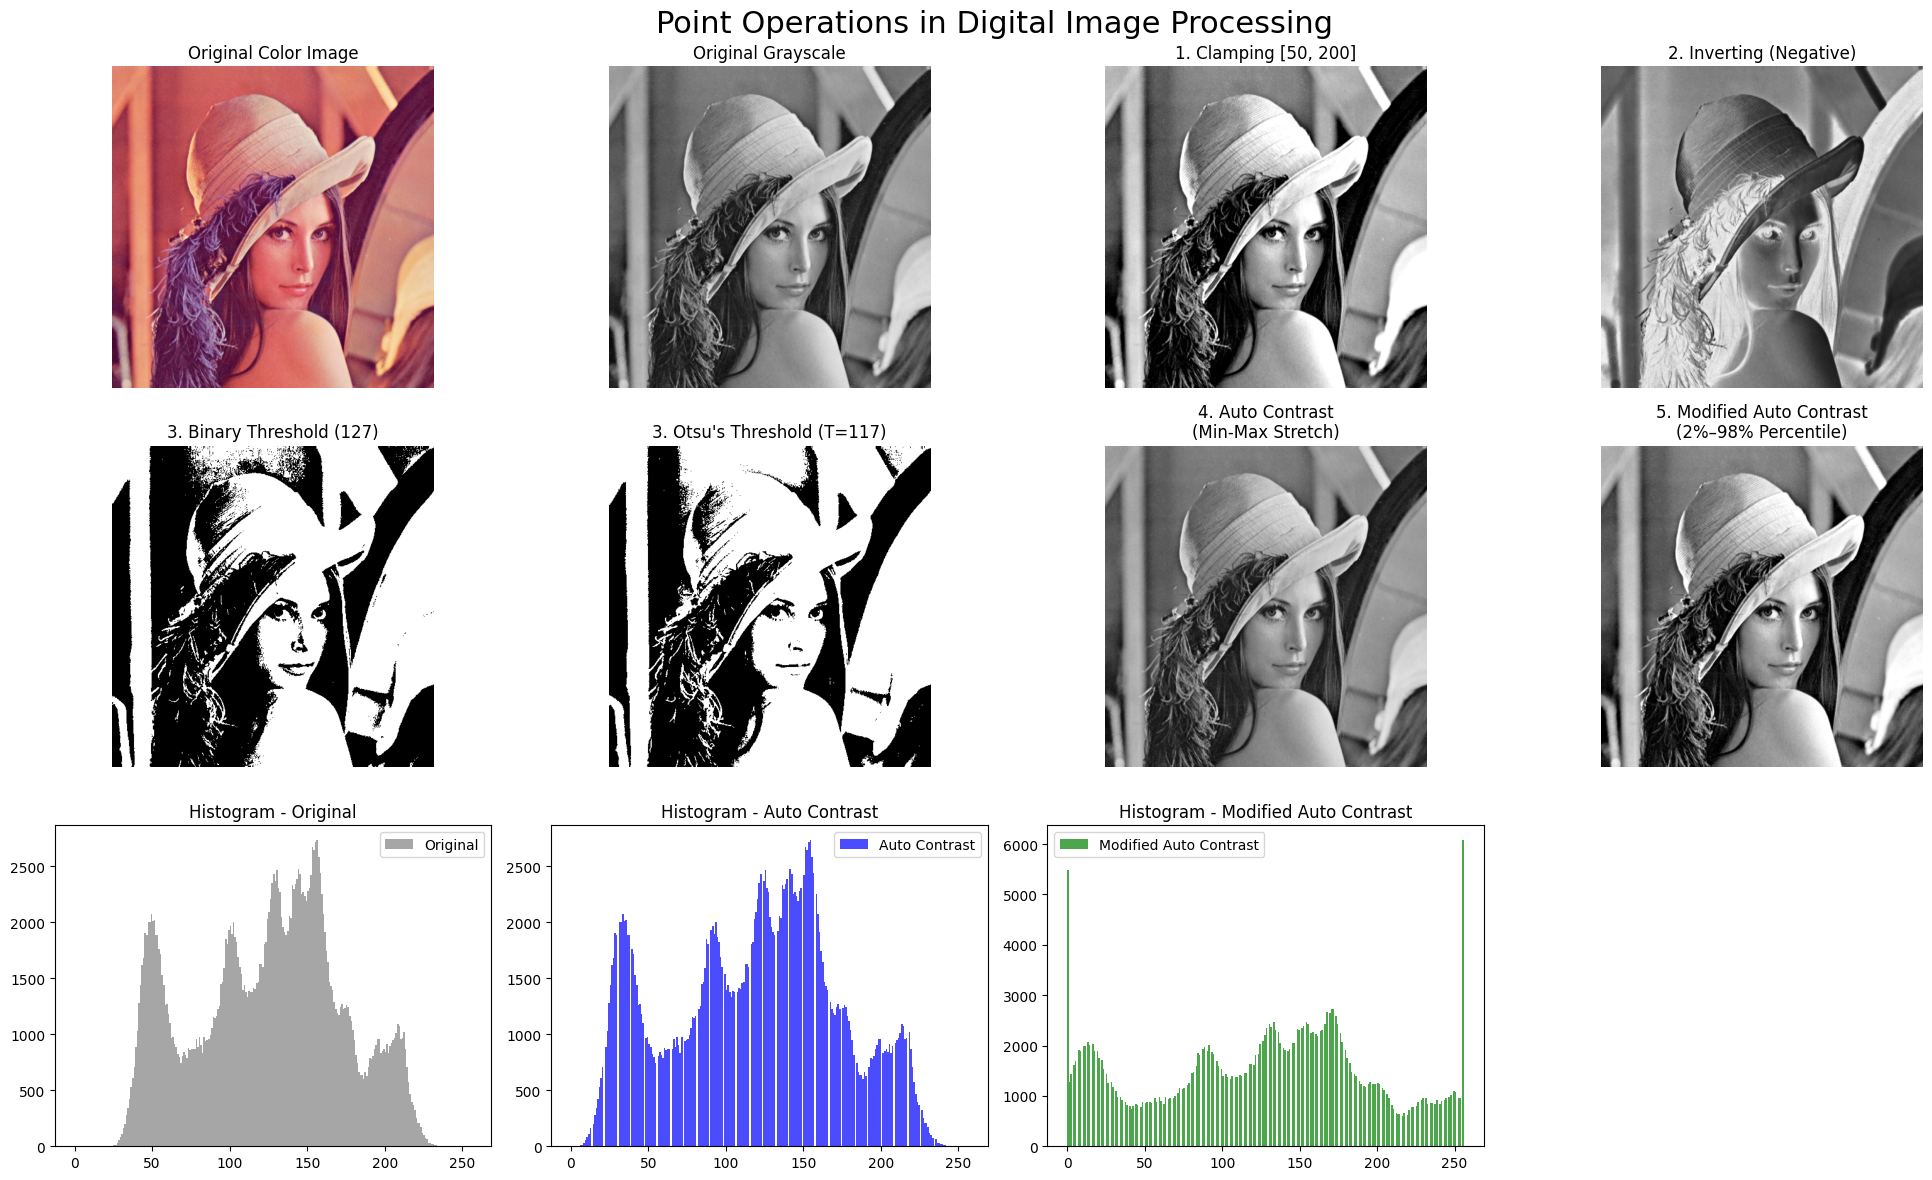

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# -------------------------------
# Download Lena if not present
# -------------------------------
if not os.path.exists('lena.jpg'):
    url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_(test_image).png'
    urllib.request.urlretrieve(url, 'lena.jpg')
    print("Lena image downloaded.")

# Load as grayscale and color
img_color = cv2.imread('lena.jpg')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

# ================================================
# 1. CLAMPING (limit pixel values to a range)
# ================================================
low, high = 50, 200
clamped = np.clip(img, low, high)                 # anything <50 → 50, >200 → 200

# ================================================
# 2. INVERTING (Negative image)
# ================================================
inverted = 255 - img

# ================================================
# 3. THRESHOLDING
# ================================================
# Manual binary threshold
_, thresh_manual = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Otsu's automatic threshold
_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ================================================
# 4. AUTO CONTRAST (simple min-max stretching)
# ================================================
auto_contrast = cv2.normalize(img, None, alpha=0, beta=255, 
                              norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Or manually:
v_min, v_max = img.min(), img.max()
auto_contrast_manual = ((img - v_min) * 255.0 / (v_max - v_min)).astype(np.uint8)

# ================================================
# 5. MODIFIED AUTO CONTRAST (percentile-based, robust to outliers)
# ================================================
low_percentile  = np.percentile(img, 2)   # ignore darkest 2%
high_percentile = np.percentile(img, 98)  # ignore brightest 2%

modified_contrast = np.clip(img, low_percentile, high_percentile)
modified_contrast = ((modified_contrast - low_percentile) * 
                     255.0 / (high_percentile - low_percentile)).astype(np.uint8)

# ================================================
# Plot everything
# ================================================
plt.figure(figsize=(20, 12))

plt.subplot(3, 4, 1)
plt.imshow(img_color)
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(clamped, cmap='gray')
plt.title(f'1. Clamping [{low}, {high}]')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(inverted, cmap='gray')
plt.title('2. Inverting (Negative)')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(thresh_manual, cmap='gray')
plt.title('3. Binary Threshold (127)')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f"3. Otsu's Threshold (T={int(cv2.threshold(img,0,255,cv2.THRESH_OTSU)[0])})")
plt.axis('off')

plt.subplot(3, 4, 7)
plt.imshow(auto_contrast, cmap='gray')
plt.title('4. Auto Contrast\n(Min-Max Stretch)')
plt.axis('off')

plt.subplot(3, 4, 8)
plt.imshow(modified_contrast, cmap='gray')
plt.title('5. Modified Auto Contrast\n(2%–98% Percentile)')
plt.axis('off')

# Histograms to show the effect
plt.subplot(3, 4, 9)
plt.hist(img.ravel(), bins=256, range=(0,256), color='gray', alpha=0.7, label='Original')
plt.title('Histogram - Original')
plt.legend()

plt.subplot(3, 4, 10)
plt.hist(auto_contrast.ravel(), bins=256, range=(0,256), color='blue', alpha=0.7, label='Auto Contrast')
plt.title('Histogram - Auto Contrast')
plt.legend()

plt.subplot(3, 4, 11)
plt.hist(modified_contrast.ravel(), bins=256, range=(0,256), color='green', alpha=0.7, label='Modified Auto Contrast')
plt.title('Histogram - Modified Auto Contrast')
plt.legend()


plt.suptitle('Point Operations in Digital Image Processing', fontsize=22, y=0.98)
plt.tight_layout()
plt.show()